# Introducción a NumPy para Visión Artificial

Máster en Inteligencia Artificial, Universidad de Murcia, curso 2026/27.

Este notebook funciona en CPU tanto en Jupyter local como en Google Colab. Para
ejecución local se utiliza el entorno descrito en `README.md` y
`requirements-base.txt`. 

Contenido basado en colección de notebooks del libro _"Hands on Machine Learning with Scikit-learn and Tensorflow"_ de Aurelien Geron ([enlace](https://machine-learning-apps.github.io/hands-on-ml2/)).

In [1]:
import platform
import sys

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Entorno:", "Google Colab" if IN_COLAB else "Jupyter local")
print("Python:", platform.python_version())

Entorno: Jupyter local
Python: 3.11.11


**Herramientas - NumPy**

NumPy es la biblioteca fundamental para la computación científica con Python. NumPy está centrado en un potente objeto de array N-dimensional, y también contiene funciones útiles de álgebra lineal, transformada de Fourier y números aleatorios.

# Creación de arrays

Primero vamos a importar `numpy`. La mayoría de la gente lo importa como `np`:

In [2]:
import numpy as np

## `np.zeros`

La función `zeros` crea un array que contiene cualquier número de ceros:

In [3]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

Es igual de sencillo crear un array 2D (es decir, una matriz) proporcionando una tupla con el número deseado de filas y columnas. Por ejemplo, aquí tienes una matriz 3x4:

In [4]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## Vocabulario básico

* En NumPy, cada dimensión se denomina **eje**.
* El número de ejes se denomina **rango**.
    * Por ejemplo, la matriz 3x4 anterior es un array de rango 2 (es bidimensional).
    * El primer eje tiene longitud 3 y el segundo longitud 4.
* La lista de longitudes de los ejes de un array se denomina **shape** del array.
    * Por ejemplo, el `shape` de la matriz anterior es `(3, 4)`.
    * El rango es igual a la longitud del `shape`.
* El **tamaño** de un array es el número total de elementos, que es el producto de todas las longitudes de los ejes (por ejemplo, 3*4=12)

In [5]:
a = np.zeros((3,4))
a

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [6]:
a.shape

(3, 4)

In [7]:
a.ndim  # igual a len(a.shape)

2

In [8]:
a.size

12

## Arrays N-dimensionales
También puedes crear un array N-dimensional de rango arbitrario. Por ejemplo, aquí tienes un array 3D (rango=3), con `shape` `(2,3,4)`:

In [9]:
np.zeros((2,3,4))

array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]])

## Tipo de array
Los arrays de NumPy tienen el tipo `ndarray`:

In [10]:
type(np.zeros((3,4)))

numpy.ndarray

## `np.ones`
Muchas otras funciones de NumPy crean `ndarray`s.

Aquí tienes una matriz 3x4 llena de unos:

In [11]:
np.ones((3,4))

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

## `np.full`
Crea un array con la forma indicada inicializado con el valor indicado. Aquí tienes una matriz 3x4 llena del número $\pi$.

In [12]:
np.full((3,4), np.pi)

array([[3.14159265, 3.14159265, 3.14159265, 3.14159265],
       [3.14159265, 3.14159265, 3.14159265, 3.14159265],
       [3.14159265, 3.14159265, 3.14159265, 3.14159265]])

## `np.empty`
Un array 2x3 no inicializado (su contenido no es predecible, ya que será lo que haya en memoria en ese momento):

In [13]:
np.empty((2,3))

array([[ 1.79769313e+308, -1.79769313e+308,  2.00000000e+000],
       [ 2.22044605e-016,  2.22507386e-308,  4.94065646e-324]])

## np.array
Por supuesto, puedes inicializar un `ndarray` usando un array normal de Python. Basta con llamar a la función `array`:

In [14]:
np.array([[1,2,3,4], [10, 20, 30, 40]])

array([[ 1,  2,  3,  4],
       [10, 20, 30, 40]])

## `np.arange`
Puedes crear un `ndarray` usando la función `arange` de NumPy, que es similar a la función integrada `range` de Python:

In [15]:
np.arange(1, 5)

array([1, 2, 3, 4])

También funciona con números en coma flotante:

In [16]:
np.arange(1.0, 5.0)

array([1., 2., 3., 4.])

Por supuesto, puedes proporcionar un parámetro de paso:

In [17]:
np.arange(1, 5, 0.5)

array([1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5])

Sin embargo, al trabajar con números en coma flotante, el número exacto de elementos del array no siempre es predecible. Por ejemplo, considera esto:

In [18]:
print(np.arange(0, 5/3, 1/3)) # según los errores de coma flotante, el valor máximo es 4/3 o 5/3.
print(np.arange(0, 5/3, 0.333333333))
print(np.arange(0, 5/3, 0.333333334))


[0.         0.33333333 0.66666667 1.         1.33333333 1.66666667]
[0.         0.33333333 0.66666667 1.         1.33333333 1.66666667]
[0.         0.33333333 0.66666667 1.         1.33333334]


## `np.linspace`
Por este motivo, en general es preferible usar la función `linspace` en lugar de `arange` cuando se trabaja con números en coma flotante. La función `linspace` devuelve un array que contiene un número específico de puntos distribuidos uniformemente entre dos valores (observa que el valor máximo se *incluye*, a diferencia de `arange`):

In [19]:
print(np.linspace(0, 5/3, 6))

[0.         0.33333333 0.66666667 1.         1.33333333 1.66666667]


## `np.rand` y `np.randn`
En el módulo `random` de NumPy hay disponibles varias funciones para crear `ndarray`s inicializados con valores aleatorios.
Por ejemplo, aquí tienes una matriz 3x4 inicializada con números aleatorios en coma flotante entre 0 y 1 (distribución uniforme):

In [20]:
np.random.rand(3,4)

array([[0.57612554, 0.26146685, 0.27013365, 0.63653555],
       [0.76134705, 0.00267475, 0.54322844, 0.28613484],
       [0.54608104, 0.24216444, 0.10016043, 0.42634691]])

Aquí tienes una matriz 3x4 que contiene números aleatorios en coma flotante muestreados de una [distribución normal](https://en.wikipedia.org/wiki/Normal_distribution) univariante (distribución gaussiana) de media 0 y varianza 1:

In [21]:
np.random.randn(3,4)

array([[-0.83942413,  1.07781582,  0.14245407, -0.22351317],
       [ 0.85796737,  0.33547104, -1.49334119,  0.46119581],
       [-1.37348012, -0.42017783, -0.12951285, -2.13893082]])

Para hacerte una idea de cómo son estas distribuciones, usemos matplotlib (consulta el tutorial de matplotlib en el _notebook_ adicional correspondiente) para más detalles):

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

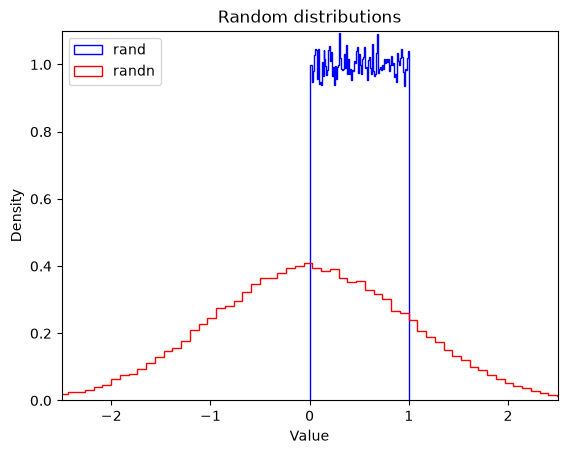

In [23]:
plt.hist(np.random.rand(100000), density=True, bins=100, histtype="step", color="blue", label="rand")
plt.hist(np.random.randn(100000), density=True, bins=100, histtype="step", color="red", label="randn")
plt.axis([-2.5, 2.5, 0, 1.1])
plt.legend(loc = "upper left")
plt.title("Random distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## np.fromfunction
También puedes inicializar un `ndarray` usando una función:

In [24]:
def my_function(z, y, x):
    return x * y + z

np.fromfunction(my_function, (3, 2, 10))

array([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.]],

       [[ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.],
        [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]],

       [[ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.],
        [ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]]])

NumPy crea primero tres `ndarrays` (uno por dimensión), cada uno con forma `(3, 2, 10)`. Cada array tiene valores iguales a la coordenada a lo largo de un eje concreto. Por ejemplo, todos los elementos del array `z` son iguales a su coordenada z:

    [[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
      [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
    
     [[ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]
      [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]
    
     [[ 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.]
      [ 2.  2.  2.  2.  2.  2.  2.  2.  2.  2.]]]

Así que los términos x, y y z de la expresión `x * y + z` anterior son en realidad `ndarray`s (más abajo hablaremos de las operaciones aritméticas con arrays). La idea es que la función `my_function` solo se llama *una vez*, en lugar de una vez por elemento. Esto hace que la inicialización sea muy eficiente.

# Datos de los arrays
## `dtype`
Los `ndarray`s de NumPy también son eficientes en parte porque todos sus elementos deben tener el mismo tipo (normalmente números).
Puedes comprobar cuál es el tipo de datos mirando el atributo `dtype`:

In [25]:
c = np.arange(1, 5)
print(c.dtype, c)

int64 [1 2 3 4]


In [26]:
c = np.arange(1.0, 5.0)
print(c.dtype, c)

float64 [1. 2. 3. 4.]


En lugar de dejar que NumPy deduzca qué tipo de datos debe usar, puedes indicarlo explícitamente al crear un array estableciendo el parámetro `dtype`:

In [27]:
d = np.arange(1, 5, dtype=np.complex64)
print(d.dtype, d)

complex64 [1.+0.j 2.+0.j 3.+0.j 4.+0.j]


Los tipos de datos disponibles incluyen `int8`, `int16`, `int32`, `int64`, `uint8`|`16`|`32`|`64`, `float16`|`32`|`64` y `complex64`|`128`. Consulta [la documentación](https://numpy.org/doc/stable/user/basics.types.html) para ver la lista completa.

## `itemsize`
El atributo `itemsize` devuelve el tamaño (en bytes) de cada elemento:

In [28]:
e = np.arange(1, 5, dtype=np.complex64)
e.itemsize

8

## _Buffer_ `data`
Los datos de un array se almacenan en realidad en memoria como un _buffer_ plano (unidimensional) de bytes. Está disponible *vía* el atributo `data` (aunque rara vez lo necesitarás).

In [29]:
f = np.array([[1,2],[1000, 2000]], dtype=np.int32)
f.data

En Python 2, `f.data` era un _buffer_. En Python 3, es ya un `memoryview`.

In [30]:
if (hasattr(f.data, "tobytes")):
    data_bytes = f.data.tobytes() # python 3
else:
    data_bytes = memoryview(f.data).tobytes() # python 2

data_bytes

b'\x01\x00\x00\x00\x02\x00\x00\x00\xe8\x03\x00\x00\xd0\x07\x00\x00'

Varios `ndarray`s pueden compartir el mismo _buffer_ de datos, lo que significa que modificar uno también modificará los demás. Veremos un ejemplo enseguida.

# Cambiar la forma de un array
## In situ
Cambiar la forma de un `ndarray` es tan sencillo como establecer su atributo `shape`. Sin embargo, el tamaño del array debe seguir siendo el mismo.

In [31]:
g = np.arange(24)
print(g)
print("Rank:", g.ndim)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Rank: 1


In [32]:
g.shape = (6, 4)
print(g)
print("Rank:", g.ndim)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]
Rank: 2


In [33]:
g.shape = (2, 3, 4)
print(g)
print("Rank:", g.ndim)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]
Rank: 3


## `reshape`
La función `reshape` devuelve un nuevo objeto `ndarray` que apunta a los *mismos* datos. Esto significa que modificar un array también modificará el otro.

In [34]:
g2 = g.reshape(4,6)
print(g2)
print("Rank:", g2.ndim)

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]
Rank: 2


Establece el elemento de la fila 1, columna 2 a 999 (más adelante veremos más sobre indexado).

In [35]:
g2[1, 2] = 999
g2

array([[  0,   1,   2,   3,   4,   5],
       [  6,   7, 999,   9,  10,  11],
       [ 12,  13,  14,  15,  16,  17],
       [ 18,  19,  20,  21,  22,  23]])

El elemento correspondiente en `g` se ha modificado.

In [36]:
g

array([[[  0,   1,   2,   3],
        [  4,   5,   6,   7],
        [999,   9,  10,  11]],

       [[ 12,  13,  14,  15],
        [ 16,  17,  18,  19],
        [ 20,  21,  22,  23]]])

## `ravel`
Por último, la función `ravel` devuelve un nuevo `ndarray` unidimensional que también apunta a los mismos datos:

In [37]:
g.ravel()

array([  0,   1,   2,   3,   4,   5,   6,   7, 999,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23])

# Operaciones aritméticas
Todos los operadores aritméticos habituales (`+`, `-`, `*`, `/`, `//`, `**`, etc.) pueden usarse con `ndarray`s. Se aplican *elemento a elemento*:

In [38]:
a = np.array([14, 23, 32, 41])
b = np.array([5,  4,  3,  2])
print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)
print("a / b  =", a / b)
print("a // b  =", a // b)
print("a % b  =", a % b)
print("a ** b =", a ** b)

a + b  = [19 27 35 43]
a - b  = [ 9 19 29 39]
a * b  = [70 92 96 82]
a / b  = [ 2.8         5.75       10.66666667 20.5       ]
a // b  = [ 2  5 10 20]
a % b  = [4 3 2 1]
a ** b = [537824 279841  32768   1681]


Observa que la multiplicación *no* es una multiplicación de matrices. Hablaremos de las operaciones matriciales más abajo.

Los arrays deben tener la misma forma. Si no la tienen, NumPy aplicará las *reglas de broadcasting*.

# _Broadcasting_

En general, cuando NumPy espera arrays de la misma forma pero encuentra que no es así, aplica las llamadas reglas de *broadcasting*:

## Primera regla
*Si los arrays no tienen el mismo rango, se antepondrá un 1 a los arrays de menor rango hasta que sus rangos coincidan.*

In [39]:
h = np.arange(5).reshape(1, 1, 5)
h

array([[[0, 1, 2, 3, 4]]])

Ahora intentemos sumar un array 1D de forma `(5,)` a este array 3D de forma `(1,1,5)`. Aplicando la primera regla de broadcasting.

In [40]:
h + [10, 20, 30, 40, 50]  # equivale a: h + [[[10, 20, 30, 40, 50]]]

array([[[10, 21, 32, 43, 54]]])

## Segunda regla
*Los arrays con un 1 en una dimensión concreta actúan como si tuvieran el tamaño del array con mayor forma en esa dimensión. El valor del elemento del array se repite a lo largo de esa dimensión.*

In [41]:
k = np.arange(6).reshape(2, 3)
k

array([[0, 1, 2],
       [3, 4, 5]])

Intentemos sumar un array 2D de forma `(2,1)` a este `ndarray` 2D de forma `(2, 3)`. NumPy aplicará la segunda regla de broadcasting:

In [42]:
k + [[100], [200]]  # equivale a: k + [[100, 100, 100], [200, 200, 200]]

array([[100, 101, 102],
       [203, 204, 205]])

Combinando las reglas 1 y 2, podemos hacer esto:

In [43]:
k + [100, 200, 300]  # después de la regla 1: [[100, 200, 300]], y después de la regla 2: [[100, 200, 300], [100, 200, 300]]

array([[100, 201, 302],
       [103, 204, 305]])

Y también, de forma muy sencilla:

In [44]:
k + 1000  # equivale a: k + [[1000, 1000, 1000], [1000, 1000, 1000]]

array([[1000, 1001, 1002],
       [1003, 1004, 1005]])

## Tercera regla
*Después de aplicar las reglas 1 y 2, los tamaños de todos los arrays deben coincidir.*

In [45]:
try:
    k + [33, 44]
except ValueError as e:
    print(e)

operands could not be broadcast together with shapes (2,3) (2,) 


Las reglas de broadcasting se usan en muchas operaciones de NumPy, no solo en operaciones aritméticas, como veremos más abajo.
Para más detalles sobre broadcasting, consulta [la documentación](https://numpy.org/doc/stable/user/basics.broadcasting.html).

## _Upcasting_
Al intentar combinar arrays con distintos `dtype`s, NumPy hará *upcast* a un tipo capaz de manejar todos los valores posibles (independientemente de cuáles sean los valores *reales*).

In [46]:
k1 = np.arange(0, 5, dtype=np.uint8)
print(k1.dtype, k1)

uint8 [0 1 2 3 4]


In [47]:
k2 = k1 + np.array([5, 6, 7, 8, 9], dtype=np.int8)
print(k2.dtype, k2)

int16 [ 5  7  9 11 13]


Observa que `int16` es necesario para representar todos los valores *posibles* de `int8` y `uint8` (de -128 a 255), aunque en este caso habría bastado un uint8.

In [48]:
k3 = k1 + 1.5
print(k3.dtype, k3)

float64 [1.5 2.5 3.5 4.5 5.5]


# Operadores condicionales

Los operadores condicionales también se aplican elemento a elemento:

In [49]:
m = np.array([20, -5, 30, 40])
m < [15, 16, 35, 36]

array([False,  True,  True, False])

Y usando broadcasting:

In [50]:
m < 25  # equivalente a m < [25, 25, 25, 25]

array([ True,  True, False, False])

Esto es especialmente útil junto con el indexado booleano (que se comenta más abajo).

In [51]:
m[m < 25]

array([20, -5])

# Funciones matemáticas y estadísticas

Hay muchas funciones matemáticas y estadísticas disponibles para `ndarray`s.

## Métodos de `ndarray`
Algunas funciones son simplemente métodos de `ndarray`; por ejemplo:

In [52]:
a = np.array([[-2.5, 3.1, 7], [10, 11, 12]])
print(a)
print("mean =", a.mean())

[[-2.5  3.1  7. ]
 [10.  11.  12. ]]
mean = 6.766666666666667


Observa que esto calcula la media de todos los elementos del `ndarray`, independientemente de su forma.

Aquí tienes algunos métodos más útiles de `ndarray`:

In [53]:
for func in (a.min, a.max, a.sum, a.prod, a.std, a.var):
    print(func.__name__, "=", func())

min = -2.5
max = 12.0
sum = 40.6
prod = -71610.0
std = 5.084835843520964
var = 25.855555555555554


Estas funciones aceptan un argumento opcional `axis`, que permite pedir que la operación se realice sobre los elementos a lo largo del eje indicado. Por ejemplo:

In [54]:
c=np.arange(24).reshape(2,3,4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [55]:
c.sum(axis=0)  # suma a través de matrices

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [56]:
c.sum(axis=1)  # suma a través de filas

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

También puedes sumar sobre varios ejes:

In [57]:
c.sum(axis=(0,2))  # suma a través de matrices y columnas

array([ 60,  92, 124])

In [58]:
0+1+2+3 + 12+13+14+15, 4+5+6+7 + 16+17+18+19, 8+9+10+11 + 20+21+22+23

(60, 92, 124)

## Funciones universales
NumPy también proporciona funciones rápidas elemento a elemento llamadas *funciones universales*, o **ufunc**. Son envoltorios vectorizados de funciones simples. Por ejemplo, `square` devuelve un nuevo `ndarray` que es una copia del `ndarray` original salvo porque cada elemento se ha elevado al cuadrado:

In [59]:
a = np.array([[-2.5, 3.1, 7], [10, 11, 12]])
np.square(a)

array([[  6.25,   9.61,  49.  ],
       [100.  , 121.  , 144.  ]])

Aquí tienes algunas ufuncs unarias útiles más:

In [60]:
print("Original ndarray")
print(a)
for func in (np.abs, np.sqrt, np.exp, np.log, np.sign, np.ceil, np.modf, np.isnan, np.cos):
    print("\n", func.__name__)
    print(func(a))

Original ndarray
[[-2.5  3.1  7. ]
 [10.  11.  12. ]]

 absolute
[[ 2.5  3.1  7. ]
 [10.  11.  12. ]]

 sqrt
[[       nan 1.76068169 2.64575131]
 [3.16227766 3.31662479 3.46410162]]

 exp
[[8.20849986e-02 2.21979513e+01 1.09663316e+03]
 [2.20264658e+04 5.98741417e+04 1.62754791e+05]]

 log
[[       nan 1.13140211 1.94591015]
 [2.30258509 2.39789527 2.48490665]]

 sign
[[-1.  1.  1.]
 [ 1.  1.  1.]]

 ceil
[[-2.  4.  7.]
 [10. 11. 12.]]

 modf
(array([[-0.5,  0.1,  0. ],
       [ 0. ,  0. ,  0. ]]), array([[-2.,  3.,  7.],
       [10., 11., 12.]]))

 isnan
[[False False False]
 [False False False]]

 cos
[[-0.80114362 -0.99913515  0.75390225]
 [-0.83907153  0.0044257   0.84385396]]


/tmp/ipykernel_163910/2634842825.py:5: RuntimeWarning: invalid value encountered in sqrt
  print(func(a))
/tmp/ipykernel_163910/2634842825.py:5: RuntimeWarning: invalid value encountered in log
  print(func(a))


## Ufuncs binarias
También hay muchas ufuncs binarias que se aplican elemento a elemento sobre dos `ndarray`s. Si los arrays no tienen la misma forma, se aplican las reglas de _broadcasting_:

In [61]:
a = np.array([1, -2, 3, 4])
b = np.array([2, 8, -1, 7])
np.add(a, b)  # equivalente a a + b

array([ 3,  6,  2, 11])

In [62]:
np.greater(a, b)  # equivalente a a > b

array([False, False,  True, False])

In [63]:
np.maximum(a, b)

array([2, 8, 3, 7])

In [64]:
np.copysign(a, b)

array([ 1.,  2., -3.,  4.])

# Indexado de arrays
## Arrays unidimensionales
Los arrays unidimensionales de NumPy se pueden acceder más o menos como los arrays normales de Python:

In [65]:
a = np.array([1, 5, 3, 19, 13, 7, 3])
a[3]

np.int64(19)

In [66]:
a[2:5]

array([ 3, 19, 13])

In [67]:
a[2:-1]

array([ 3, 19, 13,  7])

In [68]:
a[:2]

array([1, 5])

In [69]:
a[2::2]

array([ 3, 13,  3])

In [70]:
a[::-1]

array([ 3,  7, 13, 19,  3,  5,  1])

Por supuesto, puedes modificar elementos:

In [71]:
a[3]=999
a

array([  1,   5,   3, 999,  13,   7,   3])

También puedes modificar un corte (_slice_) de un `ndarray`:

In [72]:
a[2:5] = [997, 998, 999]
a

array([  1,   5, 997, 998, 999,   7,   3])

## Diferencias con los arrays normales de Python
A diferencia de los arrays normales de Python, si asignas un único valor a un corte de un `ndarray`, se copia en todo el corte, gracias a las reglas de broadcasting comentadas antes.

In [73]:
a[2:5] = -1
a

array([ 1,  5, -1, -1, -1,  7,  3])

Además, no puedes hacer crecer ni encoger `ndarray`s de esta manera:

In [74]:
try:
    a[2:5] = [1,2,3,4,5,6]  # demasiado largo
except ValueError as e:
    print(e)

could not broadcast input array from shape (6,) into shape (3,)


Tampoco puedes borrar elementos:

In [75]:
try:
    del a[2:5]
except ValueError as e:
    print(e)

cannot delete array elements


Por último, pero no por ello menos importante, los **cortes de `ndarray` son en realidad *vistas*** sobre el mismo _buffer_ de datos. Esto significa que si creas un corte y lo modificas, en realidad también modificarás el `ndarray` original.

In [76]:
a_slice = a[2:6]
a_slice[1] = 1000
a  # se ha modificado el array original

array([   1,    5,   -1, 1000,   -1,    7,    3])

In [77]:
a[3] = 2000
a_slice  # de forma similar, modificar el array original modifica el corte

array([  -1, 2000,   -1,    7])

Si quieres una copia de los datos, tienes que usar el método `copy`:

In [78]:
another_slice = a[2:6].copy()
another_slice[1] = 3000
a  # el array original queda intacto

array([   1,    5,   -1, 2000,   -1,    7,    3])

In [79]:
a[3] = 4000
another_slice  # de forma similar, modificar el array original no afecta a la copia del corte

array([  -1, 3000,   -1,    7])

## Arrays multidimensionales
Los arrays multidimensionales se pueden acceder de forma similar proporcionando un índice o corte para cada eje, separados por comas:

In [80]:
b = np.arange(48).reshape(4, 12)
b

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]])

In [81]:
b[1, 2]  # fila 1, col 2

np.int64(14)

In [82]:
b[1, :]  # fila 1, todas las columnas

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

In [83]:
b[:, 1]  # todas las filas, columna 1

array([ 1, 13, 25, 37])

**Cuidado**: observa la sutil diferencia entre estas dos expresiones:

In [84]:
b[1, :]

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23])

In [85]:
b[1:2, :]

array([[12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])

La primera expresión devuelve la fila 1 como un array 1D de forma `(12,)`, mientras que la segunda devuelve esa misma fila como un array 2D de forma `(1, 12)`.

## Indexado avanzado
También puedes especificar una lista de índices que te interesan. Esto se conoce como *fancy indexing*.

In [86]:
b[(0,2), 2:5]  # filas 0 y 2, columnas 2 a 4 (5-1)

array([[ 2,  3,  4],
       [26, 27, 28]])

In [87]:
b[:, (-1, 2, -1)]  # todas las filas, columnas -1 (última), 2 y -1 (de nuevo, y en este orden)

array([[11,  2, 11],
       [23, 14, 23],
       [35, 26, 35],
       [47, 38, 47]])

Si proporcionas varios arrays de índices, obtienes un `ndarray` 1D que contiene los valores de los elementos en las coordenadas especificadas.

In [88]:
b[(-1, 2, -1, 2), (5, 9, 1, 9)]  # devuelve un array 1D con b[-1, 5], b[2, 9], b[-1, 1] y b[2, 9] (de nuevo)

array([41, 33, 37, 33])

## Dimensiones superiores
Todo funciona igual de bien con arrays de más dimensiones, pero es útil mirar algunos ejemplos:

In [89]:
c = b.reshape(4,2,6)
c

array([[[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]],

       [[12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]],

       [[24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35]],

       [[36, 37, 38, 39, 40, 41],
        [42, 43, 44, 45, 46, 47]]])

In [90]:
c[2, 1, 4]  # matriz 2, fila 1, col 4

np.int64(34)

In [91]:
c[2, :, 3]  # matriz 2, todas las filas, col 3

array([27, 33])

Si omites coordenadas para algunos ejes, se devuelven todos los elementos de esos ejes:

In [92]:
c[2, 1]  # devuelve la matriz 2, fila 1, todas las columnas. Esto equivale a c[2, 1, :]

array([30, 31, 32, 33, 34, 35])

## Elipsis (`...`)
También puedes escribir una elipsis (`...`) para pedir que se incluyan por completo todos los ejes no especificados.

In [93]:
c[2, ...]  # matriz 2, todas las filas, todas las columnas. Esto equivale a c[2, :, :]

array([[24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35]])

In [94]:
c[2, 1, ...]  # matriz 2, fila 1, todas las columnas. Esto equivale a c[2, 1, :]

array([30, 31, 32, 33, 34, 35])

In [95]:
c[2, ..., 3]  # matriz 2, todas las filas, columna 3. Esto equivale a c[2, :, 3]

array([27, 33])

In [96]:
c[..., 3]  # todas las matrices, todas las filas, columna 3. Esto equivale a c[:, :, 3]

array([[ 3,  9],
       [15, 21],
       [27, 33],
       [39, 45]])

## Indexado booleano
También puedes proporcionar un `ndarray` de valores booleanos en un eje para especificar los índices a los que quieres acceder.

In [97]:
b = np.arange(48).reshape(4, 12)
b

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]])

In [98]:
rows_on = np.array([True, False, True, False])
b[rows_on, :]  # filas 0 y 2, todas las columnas. Equivalente a b[(0, 2), :]

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]])

In [99]:
cols_on = np.array([False, True, False] * 4)
b[:, cols_on]  # todas las filas, columnas 1, 4, 7 y 10

array([[ 1,  4,  7, 10],
       [13, 16, 19, 22],
       [25, 28, 31, 34],
       [37, 40, 43, 46]])

## `np.ix_`
No puedes usar indexado booleano de esta manera en varios ejes, pero puedes sortearlo usando la función `ix_`:

In [100]:
b[np.ix_(rows_on, cols_on)]

array([[ 1,  4,  7, 10],
       [25, 28, 31, 34]])

In [101]:
np.ix_(rows_on, cols_on)

(array([[0],
        [2]]),
 array([[ 1,  4,  7, 10]]))

Si usas un array booleano que tiene la misma forma que el `ndarray`, recibes como resultado un array 1D que contiene todos los valores que tienen `True` en su coordenada. Esto se usa generalmente junto con operadores condicionales:

In [102]:
b[b % 3 == 1]

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46])

# Iteración
Iterar sobre `ndarray`s es muy parecido a iterar sobre arrays normales de Python. Observa que la iteración sobre arrays multidimensionales se hace con respecto al primer eje.

In [103]:
c = np.arange(24).reshape(2, 3, 4)  # un array 3D (compuesto por dos matrices 3x4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [104]:
for m in c:
    print("Item:")
    print(m)

Item:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Item:
[[12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


In [105]:
for i in range(len(c)):  # observa que len(c) == c.shape[0]
    print("Item:")
    print(c[i])

Item:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Item:
[[12 13 14 15]
 [16 17 18 19]
 [20 21 22 23]]


Si quieres iterar sobre *todos* los elementos del `ndarray`, basta con iterar sobre el atributo `flat`:

In [106]:
for i in c.flat:
    print("Item:", i)

Item: 0
Item: 1
Item: 2
Item: 3
Item: 4
Item: 5
Item: 6
Item: 7
Item: 8
Item: 9
Item: 10
Item: 11
Item: 12
Item: 13
Item: 14
Item: 15
Item: 16
Item: 17
Item: 18
Item: 19
Item: 20
Item: 21
Item: 22
Item: 23


# Apilar arrays
A menudo es útil apilar arrays distintos. NumPy ofrece varias funciones para hacer precisamente eso. Empecemos creando unos cuantos arrays.

In [107]:
q1 = np.full((3,4), 1.0)
q1

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [108]:
q2 = np.full((4,4), 2.0)
q2

array([[2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.]])

In [109]:
q3 = np.full((3,4), 3.0)
q3

array([[3., 3., 3., 3.],
       [3., 3., 3., 3.],
       [3., 3., 3., 3.]])

## `vstack`
Ahora apilémoslos verticalmente usando `vstack`:

In [110]:
q4 = np.vstack((q1, q2, q3))
q4

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [3., 3., 3., 3.],
       [3., 3., 3., 3.]])

In [111]:
q4.shape

(10, 4)

Esto fue posible porque q1, q2 y q3 tienen todos la misma forma (excepto en el eje vertical, pero no pasa nada porque estamos apilando sobre ese eje).

## `hstack`
También podemos apilar arrays horizontalmente usando `hstack`:

In [112]:
q5 = np.hstack((q1, q3))
q5

array([[1., 1., 1., 1., 3., 3., 3., 3.],
       [1., 1., 1., 1., 3., 3., 3., 3.],
       [1., 1., 1., 1., 3., 3., 3., 3.]])

In [113]:
q5.shape

(3, 8)

Esto es posible porque q1 y q3 tienen ambos 3 filas. Pero como q2 tiene 4 filas, no se puede apilar horizontalmente con q1 y q3:

In [114]:
try:
    q5 = np.hstack((q1, q2, q3))
except ValueError as e:
    print(e)

all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 3 and the array at index 1 has size 4


## `concatenate`
La función `concatenate` apila arrays a lo largo de cualquier eje existente dado.

In [115]:
q7 = np.concatenate((q1, q2, q3), axis=0)  # equivalente a vstack
q7

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [3., 3., 3., 3.],
       [3., 3., 3., 3.]])

In [116]:
q7.shape

(10, 4)

Como puedes imaginar, `hstack` equivale a llamar a `concatenate` con `axis=1`.

## `stack`
La función `stack` apila arrays a lo largo de un eje nuevo. Todos los arrays deben tener la misma forma.

In [117]:
q8 = np.stack((q1, q3))
q8

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]]])

In [118]:
q8.shape

(2, 3, 4)

# Dividir arrays
Dividir es lo contrario de apilar. Por ejemplo, usemos la función `vsplit` para dividir una matriz verticalmente.

Primero creemos una matriz 6x4:

In [119]:
r = np.arange(24).reshape(6,4)
r

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

Ahora dividámosla en tres partes iguales, verticalmente:

In [120]:
r1, r2, r3 = np.vsplit(r, 3)
r1

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [121]:
r2

array([[ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [122]:
r3

array([[16, 17, 18, 19],
       [20, 21, 22, 23]])

También existe una función `split` que divide un array a lo largo de cualquier eje dado. Llamar a `vsplit` equivale a llamar a `split` con `axis=0`. También existe una función `hsplit`, equivalente a llamar a `split` con `axis=1`:

In [123]:
r4, r5 = np.hsplit(r, 2)
r4

array([[ 0,  1],
       [ 4,  5],
       [ 8,  9],
       [12, 13],
       [16, 17],
       [20, 21]])

In [124]:
r5

array([[ 2,  3],
       [ 6,  7],
       [10, 11],
       [14, 15],
       [18, 19],
       [22, 23]])

# Transponer arrays
El método `transpose` crea una nueva vista de los datos de un `ndarray`, con los ejes permutados en el orden indicado.

Por ejemplo, creemos un array 3D:

In [125]:
t = np.arange(24).reshape(4,2,3)
t

array([[[ 0,  1,  2],
        [ 3,  4,  5]],

       [[ 6,  7,  8],
        [ 9, 10, 11]],

       [[12, 13, 14],
        [15, 16, 17]],

       [[18, 19, 20],
        [21, 22, 23]]])

Ahora creemos un `ndarray` tal que los ejes `0, 1, 2` (profundidad, altura, anchura) se reordenen como `1, 2, 0` (profundidad→anchura, altura→profundidad, anchura→altura):

In [126]:
t1 = t.transpose((1,2,0))
t1

array([[[ 0,  6, 12, 18],
        [ 1,  7, 13, 19],
        [ 2,  8, 14, 20]],

       [[ 3,  9, 15, 21],
        [ 4, 10, 16, 22],
        [ 5, 11, 17, 23]]])

In [127]:
t1.shape

(2, 3, 4)

Por defecto, `transpose` invierte el orden de las dimensiones:

In [128]:
t2 = t.transpose()  # equivalente a t.transpose((2, 1, 0))
t2

array([[[ 0,  6, 12, 18],
        [ 3,  9, 15, 21]],

       [[ 1,  7, 13, 19],
        [ 4, 10, 16, 22]],

       [[ 2,  8, 14, 20],
        [ 5, 11, 17, 23]]])

In [129]:
t2.shape

(3, 2, 4)

NumPy proporciona una función cómoda, `swapaxes`, para intercambiar dos ejes. Por ejemplo, creemos una nueva vista de `t` con la profundidad y la altura intercambiadas:

In [130]:
t3 = t.swapaxes(0,1)  # equivalente a t.transpose((1, 0, 2))
t3

array([[[ 0,  1,  2],
        [ 6,  7,  8],
        [12, 13, 14],
        [18, 19, 20]],

       [[ 3,  4,  5],
        [ 9, 10, 11],
        [15, 16, 17],
        [21, 22, 23]]])

In [131]:
t3.shape

(2, 4, 3)

# Álgebra lineal
Los arrays 2D de NumPy se pueden usar para representar matrices de forma eficiente en Python. Vamos a repasar rápidamente algunas de las principales operaciones matriciales disponibles. Para más detalles sobre álgebra lineal, vectores y matrices, puedes consultar el notebook con el tutorial de álgebra lineal original de Aurelien Geron [aquí](https://machine-learning-apps.github.io/hands-on-ml2/math_linear_algebra).

## Transpuesta de una matriz
El atributo `T` equivale a llamar a `transpose()` cuando el rango es ≥2:

In [132]:
m1 = np.arange(10).reshape(2,5)
m1

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

In [133]:
m1.T

array([[0, 5],
       [1, 6],
       [2, 7],
       [3, 8],
       [4, 9]])

El atributo `T` no tiene efecto sobre arrays de rango 0 (vacíos) o rango 1:

In [134]:
m2 = np.arange(5)
m2

array([0, 1, 2, 3, 4])

In [135]:
m2.T

array([0, 1, 2, 3, 4])

Podemos obtener la transposición deseada reformando primero el array 1D como una matriz de una sola fila (2D):

In [136]:
m2r = m2.reshape(1,5)
m2r

array([[0, 1, 2, 3, 4]])

In [137]:
m2r.T

array([[0],
       [1],
       [2],
       [3],
       [4]])

## Multiplicación de matrices
Creemos dos matrices y ejecutemos una [multiplicación de matrices](https://en.wikipedia.org/wiki/Matrix_multiplication) usando el método `dot()`.

In [138]:
n1 = np.arange(10).reshape(2, 5)
n1

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

In [139]:
n2 = np.arange(15).reshape(5,3)
n2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [140]:
n1.dot(n2)

array([[ 90, 100, 110],
       [240, 275, 310]])

Se puede emplear @ como notación alternativa equivalente:

In [141]:
n1 @ n2

array([[ 90, 100, 110],
       [240, 275, 310]])

**Cuidado**: como se mencionó antes, `n1*n2` *no* es una multiplicación matricial, sino un producto elemento a elemento (también llamado [producto de Hadamard](https://en.wikipedia.org/wiki/Hadamard_product_(matrices))).

## Matriz inversa y pseudoinversa
Muchas de las funciones de álgebra lineal están disponibles en el módulo `numpy.linalg`, en particular la función `inv`, que calcula la inversa de una matriz cuadrada:

In [142]:
import numpy.linalg as linalg

m3 = np.array([[1,2,3],[5,7,11],[21,29,31]])
m3

array([[ 1,  2,  3],
       [ 5,  7, 11],
       [21, 29, 31]])

In [143]:
linalg.inv(m3)

array([[-2.31818182,  0.56818182,  0.02272727],
       [ 1.72727273, -0.72727273,  0.09090909],
       [-0.04545455,  0.29545455, -0.06818182]])

También puedes calcular la [pseudoinversa](https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_pseudoinverse) usando `pinv`:

In [144]:
linalg.pinv(m3)

array([[-2.31818182,  0.56818182,  0.02272727],
       [ 1.72727273, -0.72727273,  0.09090909],
       [-0.04545455,  0.29545455, -0.06818182]])

## Matriz identidad
El producto de una matriz por su inversa devuelve la matriz identidad (con pequeños errores de coma flotante):

In [145]:
m3.dot(linalg.inv(m3))

array([[ 1.00000000e+00, -1.66533454e-16,  0.00000000e+00],
       [ 6.31439345e-16,  1.00000000e+00, -1.38777878e-16],
       [ 5.21110932e-15, -2.38697950e-15,  1.00000000e+00]])

Puedes crear una matriz identidad de tamaño NxN llamando a `eye`:

In [146]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

## Descomposición QR
La función `qr` calcula la [descomposición QR](https://en.wikipedia.org/wiki/QR_decomposition) de una matriz:

In [147]:
q, r = linalg.qr(m3)
q

array([[-0.04627448,  0.98786672,  0.14824986],
       [-0.23137241,  0.13377362, -0.96362411],
       [-0.97176411, -0.07889213,  0.22237479]])

In [148]:
r

array([[-21.61018278, -29.89331494, -32.80860727],
       [  0.        ,   0.62427688,   1.9894538 ],
       [  0.        ,   0.        ,  -3.26149699]])

In [149]:
q.dot(r)  # q.r es igual a m3

array([[ 1.,  2.,  3.],
       [ 5.,  7., 11.],
       [21., 29., 31.]])

## Determinante
La función `det` calcula el [determinante de una matriz](https://en.wikipedia.org/wiki/Determinant):

In [150]:
linalg.det(m3)  # calcula el determinante de la matriz

np.float64(43.99999999999997)

## Autovalores y autovectores
La función `eig` calcula los [autovalores y autovectores](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors) de una matriz cuadrada:

In [151]:
eigenvalues, eigenvectors = linalg.eig(m3)
eigenvalues # λ

array([42.26600592, -0.35798416, -2.90802176])

In [152]:
eigenvectors # v

array([[-0.08381182, -0.76283526, -0.18913107],
       [-0.3075286 ,  0.64133975, -0.6853186 ],
       [-0.94784057, -0.08225377,  0.70325518]])

In [153]:
m3.dot(eigenvectors) - eigenvalues * eigenvectors  # m3.v - λ*v = 0

array([[ 6.21724894e-15,  1.66533454e-15, -3.10862447e-15],
       [ 3.55271368e-15,  5.30131494e-15, -5.32907052e-15],
       [ 3.55271368e-14,  5.38458167e-15, -9.76996262e-15]])

## Descomposición en valores singulares
La función `svd` toma una matriz y devuelve su [descomposición en valores singulares](https://en.wikipedia.org/wiki/Singular_value_decomposition):

In [154]:
m4 = np.array([[1,0,0,0,2], [0,0,3,0,0], [0,0,0,0,0], [0,2,0,0,0]])
m4

array([[1, 0, 0, 0, 2],
       [0, 0, 3, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 2, 0, 0, 0]])

In [155]:
U, S_diag, V = linalg.svd(m4)
U

array([[ 0.,  1.,  0.,  0.],
       [ 1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  1.],
       [ 0.,  0., -1.,  0.]])

In [156]:
S_diag

array([3.        , 2.23606798, 2.        , 0.        ])

La función `svd` solo devuelve los valores de la diagonal de Σ, pero queremos la matriz Σ completa, así que vamos a crearla:

In [157]:
S = np.zeros((4, 5))
S[np.diag_indices(4)] = S_diag
S  # Σ

array([[3.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 2.23606798, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 2.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [158]:
V

array([[-0.        ,  0.        ,  1.        , -0.        ,  0.        ],
       [ 0.4472136 ,  0.        ,  0.        ,  0.        ,  0.89442719],
       [ 0.        , -1.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ],
       [-0.89442719,  0.        ,  0.        ,  0.        ,  0.4472136 ]])

In [159]:
U.dot(S).dot(V) # U.Σ.V == m4

array([[1., 0., 0., 0., 2.],
       [0., 0., 3., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 2., 0., 0., 0.]])

## Diagonal y traza

In [160]:
np.diag(m3)  # los valores de la diagonal de m3 (de arriba izquierda a abajo derecha)

array([ 1,  7, 31])

In [161]:
np.trace(m3)  # equivalente a np.diag(m3).sum()

np.int64(39)

## Resolución de un sistema de ecuaciones lineales escalares

La función `solve` resuelve un sistema de ecuaciones lineales escalares, como:

* $2x + 6y = 6$
* $5x + 3y = -9$

In [162]:
coeffs  = np.array([[2, 6], [5, 3]])
depvars = np.array([6, -9])
solution = linalg.solve(coeffs, depvars)
solution

array([-3.,  2.])

Comprobemos la solución:

In [163]:
coeffs.dot(solution), depvars  # sí, es lo mismo

(array([ 6., -9.]), array([ 6, -9]))

Tiene buena pinta. Otra forma de comprobar la solución:

In [164]:
np.allclose(coeffs.dot(solution), depvars)

True

# Vectorización
En lugar de ejecutar operaciones sobre elementos individuales del array, uno cada vez, tu código será mucho más eficiente si intentas ceñirte a operaciones sobre arrays. Esto se llama *vectorización*. Así puedes beneficiarte de las muchas optimizaciones de NumPy.

Por ejemplo, supongamos que queremos generar un array 768x1024 basado en la fórmula $sin(xy/40.5)$. Una opción **mala** sería hacer los cálculos en Python usando bucles anidados:

In [165]:
import math
data = np.empty((768, 1024))
for y in range(768):
    for x in range(1024):
        data[y, x] = math.sin(x*y/40.5)  # MAL. Muy ineficiente.

Claro, esto funciona, pero es terriblemente ineficiente porque los bucles se ejecutan en Python puro. Vamos a vectorizar este algoritmo. Primero usaremos la función `meshgrid` de NumPy, que genera matrices de coordenadas a partir de vectores de coordenadas.

In [166]:
x_coords = np.arange(0, 1024)  # [0, 1, 2, ..., 1023]
y_coords = np.arange(0, 768)   # [0, 1, 2, ..., 767]
X, Y = np.meshgrid(x_coords, y_coords)
X

array([[   0,    1,    2, ..., 1021, 1022, 1023],
       [   0,    1,    2, ..., 1021, 1022, 1023],
       [   0,    1,    2, ..., 1021, 1022, 1023],
       ...,
       [   0,    1,    2, ..., 1021, 1022, 1023],
       [   0,    1,    2, ..., 1021, 1022, 1023],
       [   0,    1,    2, ..., 1021, 1022, 1023]], shape=(768, 1024))

In [167]:
Y

array([[  0,   0,   0, ...,   0,   0,   0],
       [  1,   1,   1, ...,   1,   1,   1],
       [  2,   2,   2, ...,   2,   2,   2],
       ...,
       [765, 765, 765, ..., 765, 765, 765],
       [766, 766, 766, ..., 766, 766, 766],
       [767, 767, 767, ..., 767, 767, 767]], shape=(768, 1024))

Como puedes ver, tanto `X` como `Y` son arrays 768x1024, y todos los valores de `X` corresponden a la coordenada horizontal, mientras que todos los valores de `Y` corresponden a la coordenada vertical.

Ahora podemos calcular simplemente el resultado usando operaciones con arrays:

In [168]:
data = np.sin(X*Y/40.5)

Ahora podemos representar estos datos usando la función `imshow` de matplotlib (consulta el [tutorial de matplotlib](tools_matplotlib.ipynb)).

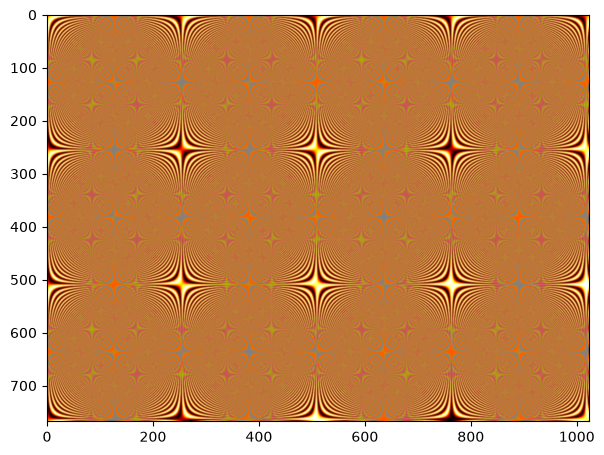

In [169]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
fig = plt.figure(1, figsize=(7, 6))
plt.imshow(data, cmap=cm.hot, interpolation="bicubic")
plt.show()

# Guardado y carga
NumPy facilita guardar y cargar `ndarray`s en formato binario o de texto.

## Formato binario `.npy`
Creemos un array aleatorio y guardémoslo.

In [170]:
a = np.random.rand(2,3)
a

array([[0.11796997, 0.15369273, 0.26467734],
       [0.3927957 , 0.89519316, 0.35198779]])

In [171]:
np.save("my_array", a)

Hecho. Como no se proporcionó ninguna extensión en el nombre del archivo, NumPy añadió automáticamente `.npy`. Echemos un vistazo al contenido del archivo:

In [172]:
with open("my_array.npy", "rb") as f:
    content = f.read()

content

b"\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fortran_order': False, 'shape': (2, 3), }                                                          \n\xa8v\x8a\xa7G3\xbe?\xa8&\x14\x0e4\xac\xc3?b\xd8\x80=y\xf0\xd0?\xc2\xf30\x98\x90#\xd9?\x07\x9f5!l\xa5\xec?\x02\xa6Y\xcd\xf7\x86\xd6?"

Para cargar este archivo en un array de NumPy, basta con llamar a `load`:

In [173]:
a_loaded = np.load("my_array.npy")
a_loaded

array([[0.11796997, 0.15369273, 0.26467734],
       [0.3927957 , 0.89519316, 0.35198779]])

## Formato de texto
Probemos a guardar el array en formato de texto:

In [174]:
np.savetxt("my_array.csv", a)

Ahora veamos el contenido del archivo:

In [175]:
with open("my_array.csv", "rt") as f:
    print(f.read())

1.179699691806158635e-01 1.536927288764691202e-01 2.646773434274846126e-01
3.927957044832589562e-01 8.951931618330214446e-01 3.519877915738051088e-01



Este es un archivo CSV con tabuladores como delimitadores. Puedes establecer un delimitador distinto:

In [176]:
np.savetxt("my_array.csv", a, delimiter=",")

Para cargar este archivo, basta con usar `loadtxt`:

In [177]:
a_loaded = np.loadtxt("my_array.csv", delimiter=",")
a_loaded

array([[0.11796997, 0.15369273, 0.26467734],
       [0.3927957 , 0.89519316, 0.35198779]])

## Formato comprimido `.npz`
También es posible guardar varios arrays en un único archivo comprimido:

In [178]:
b = np.arange(24, dtype=np.uint8).reshape(2, 3, 4)
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]], dtype=uint8)

In [179]:
np.savez("my_arrays", my_a=a, my_b=b)

De nuevo, echemos un vistazo al contenido del archivo. Observa que la extensión `.npz` se añadió automáticamente.

In [180]:
with open("my_arrays.npz", "rb") as f:
    content = f.read()

repr(content)[:180] + "[...]"

'b"PK\\x03\\x04-\\x00\\x00\\x00\\x00\\x00\\x00\\x00!\\x00\\xe3\\x01\\\\\\x03\\xff\\xff\\xff\\xff\\xff\\xff\\xff\\xff\\x08\\x00\\x14\\x00my_a.npy\\x01\\x00\\x10\\x00\\xb0\\x00\\x00\\x00\\x00\\x00\\x00\\x00\\xb0\\x00\\x00\\x00[...]'

Después cargas este archivo así:

In [181]:
my_arrays = np.load("my_arrays.npz")
my_arrays

NpzFile 'my_arrays.npz' with keys: my_a, my_b

Este es un objeto similar a un diccionario que carga los arrays de forma perezosa:

In [182]:
my_arrays.keys()

KeysView(NpzFile 'my_arrays.npz' with keys: my_a, my_b)

In [183]:
my_arrays["my_a"]

array([[0.11796997, 0.15369273, 0.26467734],
       [0.3927957 , 0.89519316, 0.35198779]])

# ¿Y ahora qué?
Ahora conoces todos los fundamentos de NumPy, pero hay muchas más opciones disponibles. La mejor forma de aprender más es experimentar con NumPy y recorrer la excelente [documentación de referencia](https://numpy.org/doc/stable/reference/) para encontrar más funciones y características que puedan interesarte.